# **ANN 6 – Write a Python Program using a Neural Network to recognize digits (0–9) from 5×3 binary patterns.**

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
# --- Data Definition ---

# Define the 5x3 patterns for numbers 0-9
training_data = {
    0: np.array([[1, 1, 1], [1, 0, 1], [1, 0, 1], [1, 0, 1], [1, 1, 1]]),
    1: np.array([[0, 1, 0], [0, 1, 0], [0, 1, 0], [0, 1, 0], [0, 1, 0]]),
    2: np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [1, 0, 0], [1, 1, 1]]),
    3: np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]),
    4: np.array([[1, 0, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [0, 0, 1]]),
    5: np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [0, 0, 1], [1, 1, 1]]),
    6: np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [1, 0, 1], [1, 1, 1]]),
    7: np.array([[1, 1, 1], [0, 0, 1], [0, 1, 0], [0, 1, 0], [0, 1, 0]]),
    8: np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [1, 0, 1], [1, 1, 1]]),
    9: np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]),
}

In [4]:
# --- Helper Functions for Visualization ---

def display_patterns(data_dict):
    """Displays the number patterns in a grid."""
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    axes = axes.flatten()
    for i, (label, pattern) in enumerate(data_dict.items()):
        axes[i].imshow(pattern, cmap='gray_r')
        axes[i].set_title(f"Label: {label}", fontsize=16)
        axes[i].set_xticks([])
        axes[i].set_yticks([])
    plt.tight_layout()
    plt.show()

def plot_training_history(history):
    """Plots accuracy and loss from the training history."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    # Plot training accuracy
    ax1.plot(history.history['accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.grid(True)
    # Plot training loss
    ax2.plot(history.history['loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.grid(True)
    plt.show()

--- Visualizing Training Data ---


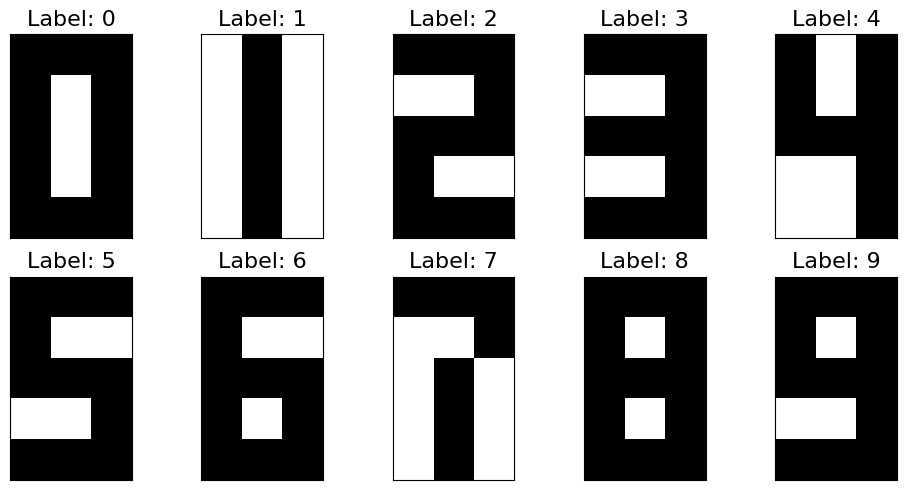

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,674 (6.54 KB)

 Trainable params: 1,674 (6.54 KB)

 Non-trainable params: 0 (0.00 B)


--- Starting Model Training ---
Training complete.


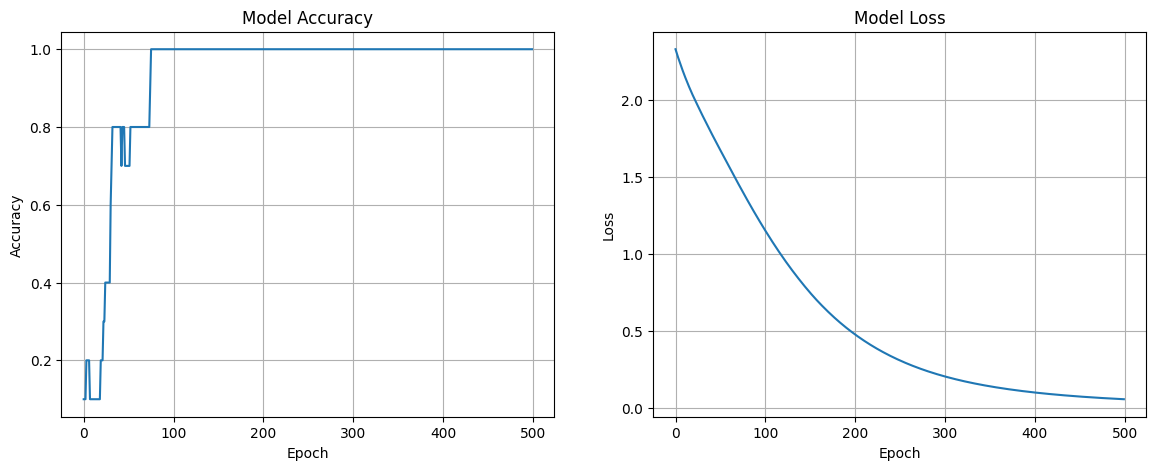


--- Testing the Trained Model ---


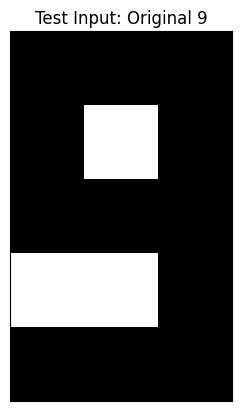

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
-> Predicted Number: 9



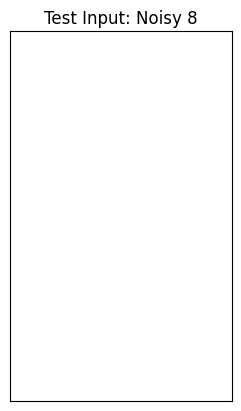

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
-> Predicted Number: 8



In [5]:
# --- Main Execution Block ---

if __name__ == "__main__":
    # 1. Visualize the training data
    print("--- Visualizing Training Data ---")
    display_patterns(training_data)

    # 2. Prepare data for TensorFlow
    # Flatten the 5x3 matrices into 15-element vectors
    x_train = np.array([v.flatten() for v in training_data.values()])
    # One-hot encode the labels
    y_train = tf.keras.utils.to_categorical(list(training_data.keys()), num_classes=10)

    # 3. Define and compile the neural network model
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(15,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax') # Softmax for multi-class classification
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()

    # 4. Train the model and plot its progress
    print("\n--- Starting Model Training ---")
    # Using verbose=0 to keep the output clean for this report
    history = model.fit(x_train, y_train, epochs=500, verbose=0) 
    print("Training complete.")
    plot_training_history(history)
    
    # 5. Test the model with a known and a noisy pattern
    print("\n--- Testing the Trained Model ---")
    
    # Test case 1: The original pattern for the number 9
    test_pattern_9 = training_data[9]
    
    # Test case 2: A corrupted version of the number 8 (flipped 2 pixels)
    test_pattern_8_noisy = training_data[8].copy()
    test_pattern_8_noisy[1, 1] = 1 # Change 0 to 1
    test_pattern_8_noisy[3, 1] = 1 # Change 0 to 1
    
    test_cases = {
        "Original 9": test_pattern_9,
        "Noisy 8": test_pattern_8_noisy
    }
    
    for name, pattern in test_cases.items():
        # Display the pattern being tested
        plt.imshow(pattern, cmap='gray_r')
        plt.title(f"Test Input: {name}")
        plt.xticks([])
        plt.yticks([])
        plt.show()

        # Predict the number
        prediction = model.predict(np.array([pattern.flatten()]))
        predicted_number = np.argmax(prediction)
        print(f"-> Predicted Number: {predicted_number}\n")